  
📊 Exploratory Data Analysis (EDA)
1. Basic Summary Statistics
Objective: Get an overview of the dataset.


Tools: pandas


Tasks:


Use .info() and .describe() to view data types and distributions.


Count null or missing values in each column.


Value counts of categorical columns like learning_mode, student_id, etc.


2. Daily Average Engagement and Attention
Objective: Track how student attention/engagement varies daily.


Tools: pandas, matplotlib.pyplot


Tasks:


Group by date and calculate average attention and engagement.


Plot line charts for daily trends.


3. Most and Least Engaged Students
Objective: Identify students who consistently perform well or poorly.


Tools: pandas, numpy, matplotlib


Tasks:


Group by student_id and average engagement or attention.


Sort and display top/bottom 10 students using a bar chart.
🧠 Behavioral Pattern Analysis
4. Engagement by Learning Mode
Objective: Analyze which learning modes lead to higher engagement.


Tools: pandas, matplotlib


Tasks:


Group by learning_mode and compute average engagement.


Plot a bar chart to compare modes.





---- DATA INFO ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Student ID                10000 non-null  int64 
 1   Session ID                10000 non-null  int64 
 2   Date                      10000 non-null  object
 3   EEG Data (PSD Features)   10000 non-null  object
 4   Engagement Level          10000 non-null  object
 5   Attention Level           10000 non-null  object
 6   Internet Connectivity     10000 non-null  object
 7   Adaptivity Level          10000 non-null  object
 8   Learning Mode Prediction  10000 non-null  object
 9   Performance Metrics       10000 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 781.4+ KB
None

---- SUMMARY ----
         Student ID    Session ID        Date  \
count   10000.00000  10000.000000       10000   
unique          NaN           NaN          30   
t

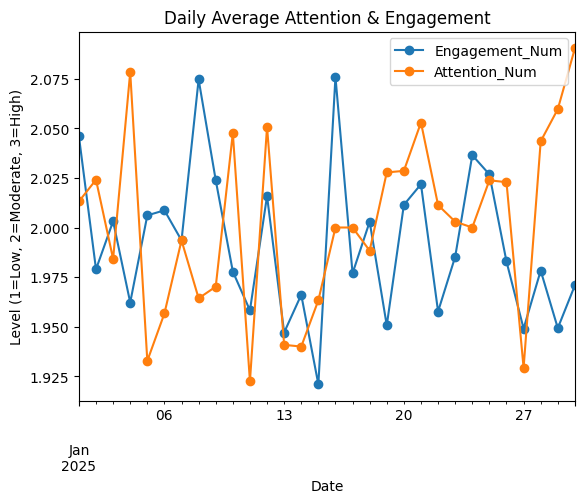


Top 10 Students:
             Engagement_Num  Attention_Num  Performance Metrics
Student ID                                                    
9984                   3.0            1.0                 79.0
9982                   3.0            1.0                 81.0
9980                   3.0            2.0                 58.0
9979                   3.0            3.0                 81.0
9976                   3.0            2.0                 99.0
9975                   3.0            3.0                 99.0
9972                   3.0            2.0                 53.0
9970                   3.0            3.0                 93.0
32                     3.0            2.0                 92.0
31                     3.0            3.0                 89.0


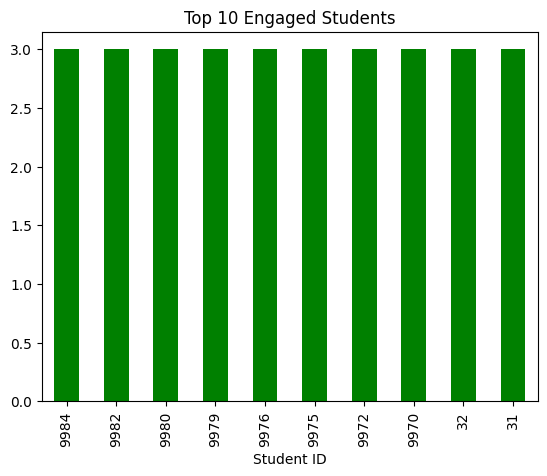


Bottom 10 Students:
             Engagement_Num  Attention_Num  Performance Metrics
Student ID                                                    
47                     1.0            2.0                 84.0
48                     1.0            1.0                 61.0
6                      1.0            1.0                 69.0
9                      1.0            3.0                 87.0
9985                   1.0            1.0                 76.0
9986                   1.0            1.0                 96.0
9988                   1.0            2.0                 51.0
9990                   1.0            1.0                 50.0
9991                   1.0            2.0                 85.0
3366                   1.0            3.0                 87.0


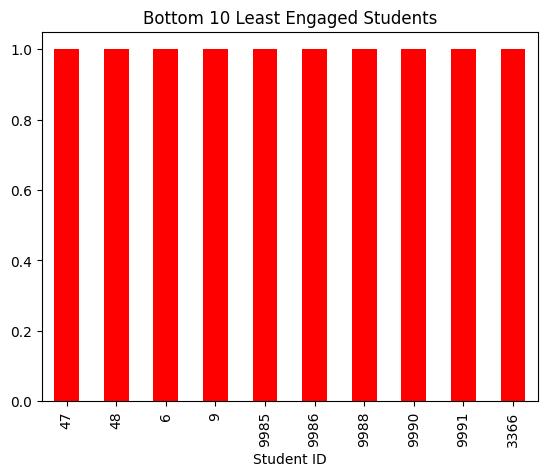


Average Engagement by Learning Mode:
 Learning Mode Prediction
Auditory Learner       2.015334
Kinesthetic Learner    1.977771
Visual Learner         1.980303
Name: Engagement_Num, dtype: float64


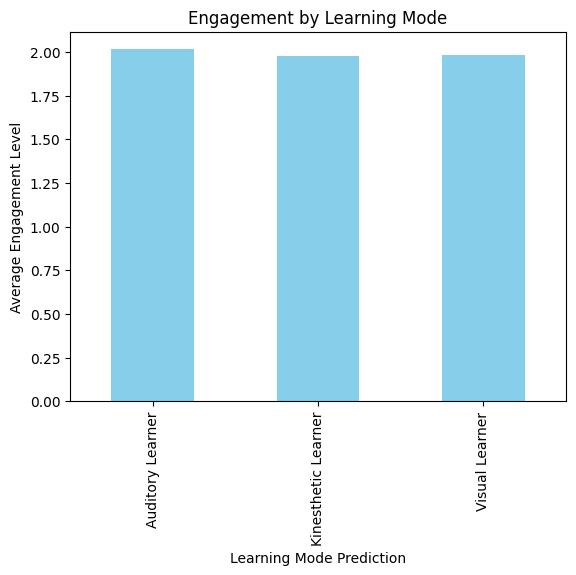

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# File load karna
df = pd.read_csv("student_engagement_data_10000.csv")


# 1. Basic Summary Statistics

print("---- DATA INFO ----")
print(df.info())

print("\n---- SUMMARY ----")
print(df.describe(include="all"))

print("\n---- MISSING VALUES ----")
print(df.isnull().sum())

print("\nEngagement Level Counts:\n", df["Engagement Level"].value_counts())
print("\nAttention Level Counts:\n", df["Attention Level"].value_counts())
print("\nLearning Mode Counts:\n", df["Learning Mode Prediction"].value_counts())


# 2. Daily Average Attention & Engagement

# Convert text to numbers
eng_map = {"Low": 1, "Moderate": 2, "High": 3}
att_map = {"Low": 1, "Moderate": 2, "High": 3}

df["Engagement_Num"] = df["Engagement Level"].map(eng_map)
df["Attention_Num"] = df["Attention Level"].map(att_map)

# Date column format
df["Date"] = pd.to_datetime(df["Date"])

daily = df.groupby("Date")[["Engagement_Num","Attention_Num"]].mean()
print("\nDaily Average:\n", daily.head())

# Line chart
daily.plot(title="Daily Average Attention & Engagement", marker="o")
plt.ylabel("Level (1=Low, 2=Moderate, 3=High)")
plt.show()


# 3. Most and Least Engaged Students

student_avg = df.groupby("Student ID")[["Engagement_Num","Attention_Num","Performance Metrics"]].mean()

# Top 10
top = student_avg.sort_values("Engagement_Num", ascending=False).head(10)
print("\nTop 10 Students:\n", top)

top["Engagement_Num"].plot(kind="bar", title="Top 10 Engaged Students", color="green")
plt.show()

# Bottom 10
bottom = student_avg.sort_values("Engagement_Num").head(10)
print("\nBottom 10 Students:\n", bottom)

bottom["Engagement_Num"].plot(kind="bar", title="Bottom 10 Least Engaged Students", color="red")
plt.show()


# 4. Engagement by Learning Mode

mode_avg = df.groupby("Learning Mode Prediction")["Engagement_Num"].mean()
print("\nAverage Engagement by Learning Mode:\n", mode_avg)

mode_avg.plot(kind="bar", title="Engagement by Learning Mode", color="skyblue")
plt.ylabel("Average Engagement Level")
plt.show()
